#### VU Data Mining Techniques — Assignment 2
#### Predicting Hotel Booking Likelihood (Expedia Kaggle)


#### Note on Task 1 — Business Understanding (Related Work)

Task 1 (the *Related Work* section discussing prior approaches to the original
Expedia Personalize ICDM 2013 Kaggle competition and the predictors that previous
participants found most informative) is handled separately as part of the written
report by one of our group members. It is **not** part of this code notebook.

This notebook therefore covers **Tasks 2 through 5**:

| Task | Section | Grounded in |
|---|---|---|
| 2 — Data Understanding (EDA) | §1 | Lectures 1, 2 |
| 3 — Data Preparation | §2 | Lecture 2 |
| 4 — Modelling and Evaluation | §3 | Lectures 4, 5, 6, 7 |
| 5 — Deployment + Bias Investigation | §4 | Lecture 8 |
| Kaggle Submission file | §5 | — |


#### §0 — Setup and Environment Check

Before we touch the data, we verify that all the libraries we will use are installed
and that the three input CSV files (training set, test set, and a sample submission)
are present in the working directory. This is a fail-fast check: if anything is
missing here, we fix it before spending an hour debugging a deeper problem.


In [10]:
# =============================================================================
# Robust install — diagnose Python environment, then install into it
# =============================================================================
# `sys.executable` is the absolute path to the Python interpreter the Jupyter
# kernel is currently using. The leading `!` makes Jupyter run the rest of the
# line as a shell command, and `{...}` interpolates the Python variable inside.
# Calling `<python> -m pip install ...` is the most reliable way to install
# into the *exact* environment running this notebook (rather than whichever
# `pip` happens to be on the system PATH).
# =============================================================================

import sys

# 1) Show which Python Jupyter is using — useful if anything looks off.
print(f"Jupyter is using Python at: {sys.executable}")
print()

# 2) Install scikit-learn and lightgbm into that exact Python.
!{sys.executable} -m pip install scikit-learn lightgbm


Jupyter is using Python at: /usr/local/bin/python3


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [11]:
# =============================================================================
# §0 — Setup and Environment Check
# =============================================================================
# Purpose: verify our Python environment and confirm that the three Expedia CSV
# files are accessible before we start any real work.
# =============================================================================

# ---- Standard-library imports ------------------------------------------------
import os    # for file path / size checks
import sys   # for printing the Python version

# ---- Third-party data-science libraries --------------------------------------

# `pandas` is THE library for tabular data in Python. A DataFrame is essentially
# an in-memory Excel sheet that we can filter, group, join, and compute on.
import pandas as pd

# `numpy` provides fast numeric arrays and math operations. pandas uses numpy
# under the hood, so we'll often see it in error messages even when we don't
# call it directly.
import numpy as np

# Plotting libraries for EDA. `matplotlib` is the foundation of Python plotting;
# `seaborn` is a higher-level wrapper that produces prettier statistical plots
# with one-line calls. We'll use seaborn for most EDA plots in Task 2.
import matplotlib.pyplot as plt
import seaborn as sns

# `scikit-learn` (imported as `sklearn`) is the standard general-purpose ML
# library. We'll use it for train/validation splitting, the logistic-regression
# baseline model, and several evaluation metrics.
import sklearn

# `lightgbm` is Microsoft's gradient-boosted-tree library. It implements
# LambdaMART — the listwise learning-to-rank algorithm that is the standard
# approach for search-results-ranking tasks. This is the technique we use to
# satisfy the assignment's requirement of "at least one technique from the
# Recommender Systems lecture (or a variant thereof)" — learning-to-rank is
# the algorithmic core of how Expedia (and similar services) personalise
# search rankings.
import lightgbm as lgb


# ---- Step 1: print versions for reproducibility ------------------------------
print("Environment versions")
print("-" * 40)
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"lightgbm    : {lgb.__version__}")
print()


# ---- Step 2: verify the three input CSV files are present --------------------
DATA_FILES = {
    "training": "training_set_VU_DM.csv",   # ~1.27 GB — has click_bool, booking_bool labels
    "test":     "test_set_VU_DM.csv",       # ~1.21 GB — no labels; this is what Kaggle scores
    "sample":   "submission_sample.csv",    # ~63 MB — shows the required submission format
}

print("Data files in working directory")
print("-" * 40)
for label, filename in DATA_FILES.items():
    if os.path.exists(filename):
        size_gb = os.path.getsize(filename) / (1024 ** 3)
        print(f"  [OK]    {label:<8} : {filename}  ({size_gb:.2f} GB)")
    else:
        print(f"  [MISS]  {label:<8} : {filename}  -- file not found in working directory!")

print()
print("Setup check complete.")
print("If any file is marked [MISS] above, fix the path or download the file before continuing.")


Environment versions
----------------------------------------
Python      : 3.13.3
pandas      : 2.2.3
numpy       : 2.2.4
scikit-learn: 1.8.0
lightgbm    : 4.6.0

Data files in working directory
----------------------------------------
  [OK]    training : training_set_VU_DM.csv  (1.18 GB)
  [OK]    test     : test_set_VU_DM.csv  (1.13 GB)
  [OK]    sample   : submission_sample.csv  (0.06 GB)

Setup check complete.
If any file is marked [MISS] above, fix the path or download the file before continuing.


#### §1 — Task 2: Data Understanding (Exploratory Data Analysis)

In this section we explore the data before committing to a model. We follow the
EDA workflow from Lecture 2: (1) check data quality and logical structure,
(2) explore distributions and dependencies, and (3) identify candidate features
and their importance.

The Expedia training set contains roughly 5 million rows, where each row represents
**one (search query × hotel property) pair** that was shown to a user. The training
rows additionally carry `click_bool` and `booking_bool` labels indicating whether
the user clicked the hotel and whether they actually booked it. These are the
signals the ranker must learn to predict.

> *Tip for the report:* the rubric awards 5 points for "Dataset statistics", 5 for
> "Plots", and 10 for "Rationale and interpretation" — so each plot below should
> be followed in the report by 1–2 sentences explaining what it means.


In [12]:
# =============================================================================
# Cell 1 — Quick peek at the training data
# =============================================================================
# Purpose: load just the first 1,000 rows of the training CSV so we can inspect
# the schema (column names, data types, sample values) WITHOUT paying the cost
# of loading all ~5 million rows.
#
# Why this matters: the full training file is 1.18 GB on disk and would
# typically expand to several GB in memory under pandas' default dtypes. By
# peeking first, the next cell can load the full file with carefully chosen
# dtypes that fit in RAM comfortably.
# =============================================================================

# ---- 1) Read only the first 1,000 rows ----
# `pd.read_csv()` loads a CSV file into a DataFrame (the pandas table object).
# `nrows=1000` tells it to stop after 1,000 data rows — extremely fast.
# We deliberately do NOT tell pandas the dtypes here; we want to see what it
# INFERS automatically, so we can tighten them in the next cell.
train_peek = pd.read_csv("training_set_VU_DM.csv", nrows=1000)


# ---- 2) Report shape ----
# `.shape` is a (rows, columns) tuple. The `{:,}` format adds thousands
# separators to make big numbers readable.
print(f"Sample shape: {train_peek.shape[0]:,} rows × {train_peek.shape[1]} columns")
print()


# ---- 3) Show every column and its inferred dtype ----
# `.dtypes` returns a pandas Series listing each column → its data type.
# `.to_string()` forces it to print ALL rows instead of truncating with "...".
# Reading this output tells us:
#   - which columns are integers / floats / objects (strings)
#   - whether dtypes look reasonable (e.g. an "id" column should be integer)
#   - which columns will need conversion (e.g. dates currently parsed as object)
print("Columns and inferred dtypes:")
print("-" * 60)
print(train_peek.dtypes.to_string())
print()


# ---- 4) Show the first 5 rows of actual data ----
# `.head(5)` returns the first 5 rows. Helps us eyeball real values to spot
# anomalies (e.g. negative prices, suspicious zeros, weird text).
# `pd.option_context(...)` is a temporary settings block — inside the `with`,
# pandas is told to show ALL columns and not truncate the table width.
print("First 5 rows of the sample:")
print("-" * 60)
with pd.option_context("display.max_columns", None, "display.width", None):
    print(train_peek.head(5))


Sample shape: 1,000 rows × 54 columns

Columns and inferred dtypes:
------------------------------------------------------------
srch_id                          int64
date_time                       object
site_id                          int64
visitor_location_country_id      int64
visitor_hist_starrating        float64
visitor_hist_adr_usd           float64
prop_country_id                  int64
prop_id                          int64
prop_starrating                  int64
prop_review_score              float64
prop_brand_bool                  int64
prop_location_score1           float64
prop_location_score2           float64
prop_log_historical_price      float64
position                         int64
price_usd                      float64
promotion_flag                   int64
srch_destination_id              int64
srch_length_of_stay              int64
srch_booking_window              int64
srch_adults_count                int64
srch_children_count              int64
srch_room_cou

In [13]:
# =============================================================================
# Cell 2 — Load the full training data with optimised dtypes
# =============================================================================
# Purpose: load the FULL ~5 million-row training file into memory once, using
# carefully chosen smaller data types. This is a textbook "data reduction by
# type narrowing" step from Lecture 2 (EDA: data quality and reduction).
#
# Why override the dtypes pandas inferred in Cell 1:
#   - pandas defaults to `int64` (8 bytes per value) and `float64` (8 bytes).
#   - Switching `int8` (1 byte) for 0/1 columns and `float32` (4 bytes) for
#     floats cuts memory in half — roughly 5 GB → 1.5 GB on this dataset.
#   - Half the memory ⇒ groupby / filter / plot operations run roughly twice
#     as fast and we leave headroom for the test set later.
# =============================================================================

import time  # standard library; used here only to measure how long the load takes

# ---- 1) Build the dtype dictionary -----------------------------------------
# Each entry maps a column name → the smallest dtype that safely holds all its
# values. Choices come from the inferred dtypes in Cell 1 plus the variable
# description table in the assignment PDF.

TRAIN_DTYPES = {
    # --- IDs: need int32 (signed 32-bit) because they exceed int16 max (~32k) ---
    "srch_id":                     "int32",
    "site_id":                     "int8",    # only ~30 distinct Expedia sites
    "visitor_location_country_id": "int16",
    "prop_country_id":             "int16",
    "prop_id":                     "int32",   # ~140k unique hotel IDs
    "srch_destination_id":         "int32",

    # --- Small bounded integers ---
    "prop_starrating":             "int8",    # 0..5
    "prop_brand_bool":             "int8",    # 0/1
    "position":                    "int16",   # 1..~40
    "promotion_flag":              "int8",    # 0/1
    "srch_length_of_stay":         "int8",    # rarely above ~30 nights
    "srch_booking_window":         "int16",   # up to ~500 days into the future
    "srch_adults_count":           "int8",
    "srch_children_count":         "int8",
    "srch_room_count":             "int8",
    "srch_saturday_night_bool":    "int8",    # 0/1
    "random_bool":                 "int8",    # 0/1
    "click_bool":                  "int8",    # 0/1  ← training-only label
    "booking_bool":                "int8",    # 0/1  ← training-only label

    # --- Floats: 4-byte float32 instead of 8-byte float64; precision is plenty ---
    "visitor_hist_starrating":     "float32",
    "visitor_hist_adr_usd":        "float32",
    "prop_review_score":           "float32",
    "prop_location_score1":        "float32",
    "prop_location_score2":        "float32",
    "prop_log_historical_price":   "float32",
    "price_usd":                   "float32",
    "srch_query_affinity_score":   "float32",
    "orig_destination_distance":   "float32",
    "gross_bookings_usd":          "float32",
}

# The 8 competitor groups (comp1..comp8) each contribute 3 columns.
# Building them in a loop is more compact than typing all 24 names by hand —
# and adapts automatically if the data schema ever changes.
for i in range(1, 9):
    TRAIN_DTYPES[f"comp{i}_rate"]              = "float32"   # -1, 0, 1 or NaN
    TRAIN_DTYPES[f"comp{i}_inv"]               = "float32"   # 0, 1 or NaN
    TRAIN_DTYPES[f"comp{i}_rate_percent_diff"] = "float32"


# ---- 2) Load the full file with the optimised dtypes -----------------------
# `parse_dates=["date_time"]` tells pandas to convert that column from a plain
# string into a true `datetime64` object. This makes later date arithmetic
# (e.g. extracting hour-of-day, day-of-week) cheap and idiomatic.
print("Loading the full training set... (expect ~30–90 seconds)")
t0 = time.time()

train = pd.read_csv(
    "training_set_VU_DM.csv",
    dtype=TRAIN_DTYPES,
    parse_dates=["date_time"],
)

elapsed = time.time() - t0
print(f"Done. Loaded in {elapsed:.1f} seconds.")
print()


# ---- 3) Report shape, memory usage, and a couple of basic sanity stats -----
# `.shape` gives (rows, cols).
# `.memory_usage(deep=True).sum()` totals real bytes used across all columns.
# `.nunique()` counts distinct values — for `srch_id` this is the number of
# unique search queries in the file (each query has multiple displayed hotels).

mem_mb = train.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Full training set shape  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"In-memory size           : {mem_mb:,.0f} MB")
print(f"Number of unique searches: {train['srch_id'].nunique():,}")
print(f"Date range               : {train['date_time'].min()}  →  {train['date_time'].max()}")


Loading the full training set... (expect ~30–90 seconds)
Done. Loaded in 15.0 seconds.

Full training set shape  : 4,958,347 rows × 54 columns
In-memory size           : 832 MB
Number of unique searches: 199,795
Date range               : 2012-11-01 00:08:29  →  2013-06-30 23:58:24


Columns with at least one missing value: 31 of 54

                           missing_count  missing_pct
comp1_rate_percent_diff          4863908        98.10
comp6_rate_percent_diff          4862173        98.06
comp1_rate                       4838417        97.58
comp1_inv                        4828788        97.39
comp4_rate_percent_diff          4827261        97.36
comp7_rate_percent_diff          4819832        97.21
gross_bookings_usd               4819957        97.21
comp6_rate                       4718190        95.16
visitor_hist_starrating          4706481        94.92
visitor_hist_adr_usd             4705359        94.90
comp6_inv                        4697371        94.74
comp4_rate                       4650969        93.80
comp7_rate                       4642999        93.64
srch_query_affinity_score        4640941        93.60
comp4_inv                        4614684        93.07
comp7_inv                        4601925        92.81
comp3_rate_percent_diff        

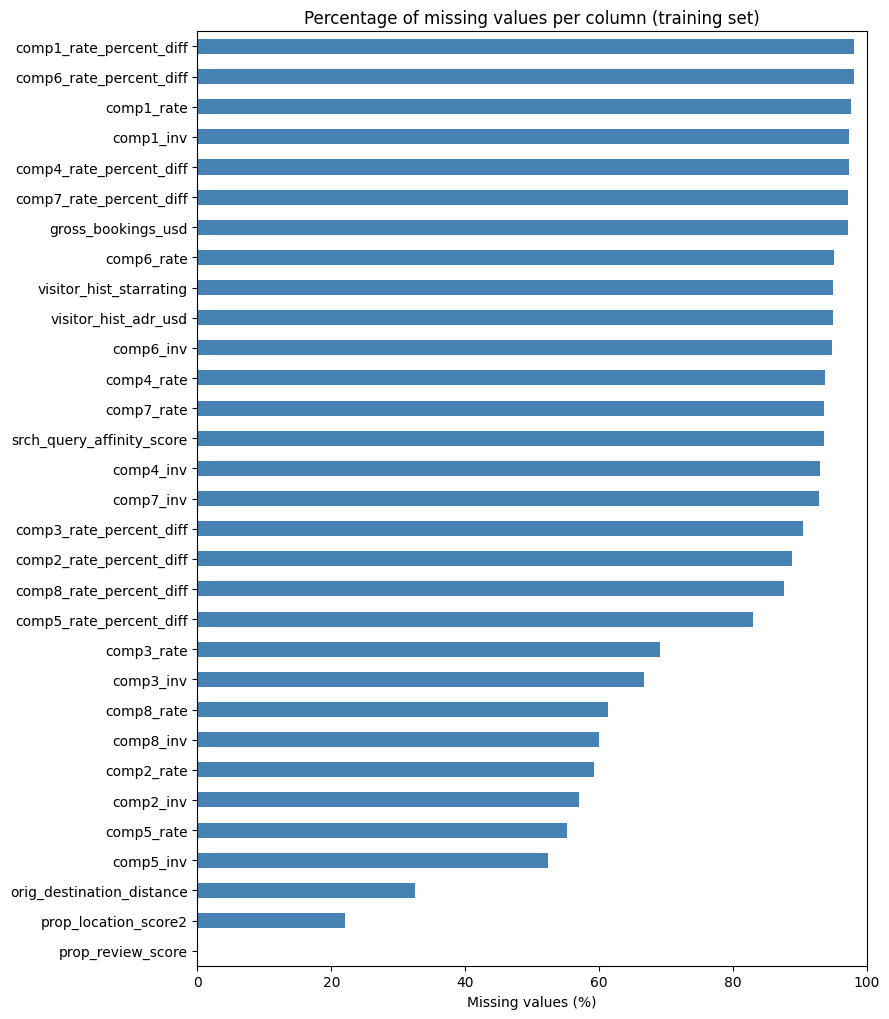

In [14]:
# =============================================================================
# Cell 3 — Missing-value overview (data quality, Lecture 2)
# =============================================================================
# Purpose: report which columns have NaN values, how many, and visualise
# the percentages. This is the "data quality" step from Lecture 2's EDA
# workflow. The result directly determines our Task 3 feature-engineering
# decisions (drop / impute / carry-forward) for each affected column.
# =============================================================================

# ---- 1) Build the missing-value summary table ------------------------------
# `train.isna()` returns a DataFrame of the same shape where every cell is
# True if the original value was NaN and False otherwise.
# `.sum()` then sums the True values down each column (True counts as 1 in
# arithmetic), giving us a Series mapping column name → number of NaNs.
missing_counts = train.isna().sum()

# Convert counts into percentages of total rows. `len(train)` is the row count.
# `.round(2)` keeps two decimal places for readability.
missing_pct = (missing_counts / len(train) * 100).round(2)

# Assemble both into a small DataFrame, sorted from most-missing to least.
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct":   missing_pct,
}).sort_values("missing_pct", ascending=False)

# Drop the rows where missing_count == 0 — those columns are fine and would
# just clutter the output.
missing_summary_nz = missing_summary[missing_summary["missing_count"] > 0]

print(f"Columns with at least one missing value: "
      f"{len(missing_summary_nz)} of {train.shape[1]}")
print()
# `.to_string()` prints the whole table without pandas' default truncation.
print(missing_summary_nz.to_string())


# ---- 2) Plot the % missing per column --------------------------------------
# We pick a horizontal bar chart so the (long) column names sit on the y-axis
# and remain readable. Bar height is auto-scaled to the number of columns
# shown so each row gets ~0.3 inches of vertical space.
fig, ax = plt.subplots(figsize=(9, 0.3 * len(missing_summary_nz) + 1))

# `.sort_values()` (default ascending) puts the longest bar at the top of the
# chart — visually easier to scan than descending.
missing_summary_nz["missing_pct"].sort_values().plot.barh(ax=ax, color="steelblue")

ax.set_xlabel("Missing values (%)")
ax.set_title("Percentage of missing values per column (training set)")
ax.set_xlim(0, 100)         # always use the full 0–100% range for fair comparison
plt.tight_layout()           # avoid label clipping
plt.show()


Total rows                  : 4,958,347
Total searches              : 199,795

Rows with click_bool == 1   : 221,879   (4.47%)
Rows with booking_bool == 1 : 138,390   (2.79%)

Avg clicks per search       : 1.11
Avg bookings per search     : 0.69

Relevance-grade distribution (used by NDCG@5):
-------------------------------------------------------
  grade 0:  4,736,468 rows  (95.53%)
  grade 1:     83,489 rows  ( 1.68%)
  grade 5:    138,390 rows  ( 2.79%)



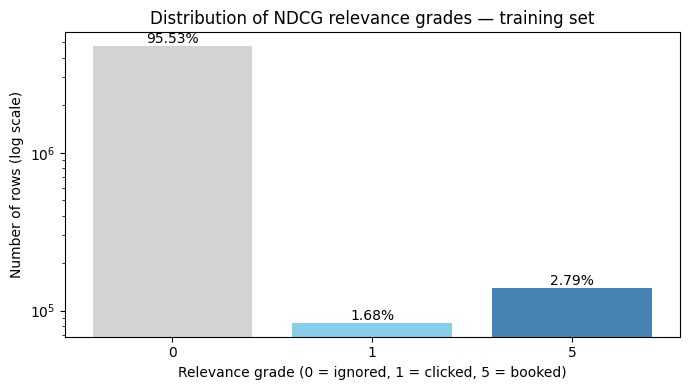

In [15]:
# =============================================================================
# Cell 4 — Target label distribution and NDCG@5 relevance grades
# =============================================================================
# Purpose: understand how rare clicks and bookings are, and construct the
# 3-class relevance grade that NDCG@5 uses (5 = booked, 1 = clicked-only,
# 0 = ignored). This grade is also what LambdaMART (our main model) will be
# trained against in Task 4.
#
# Why it matters: in a ranking task with severe class imbalance, "accuracy"
# is useless — predicting "no booking" for every row would already be ~97%
# accurate. The lecture-recommended metric here is NDCG@5 (Lecture 7 /
# assignment PDF), which directly rewards putting the rare booked-/clicked
# hotels at the top of each search's ranking.
# =============================================================================

# ---- 1) Basic label statistics ---------------------------------------------
n_rows     = len(train)
n_clicks   = int(train["click_bool"].sum())     # cast to int for nicer printing
n_bookings = int(train["booking_bool"].sum())
n_searches = train["srch_id"].nunique()

print(f"Total rows                  : {n_rows:,}")
print(f"Total searches              : {n_searches:,}")
print()
print(f"Rows with click_bool == 1   : {n_clicks:,}   ({n_clicks/n_rows*100:.2f}%)")
print(f"Rows with booking_bool == 1 : {n_bookings:,}   ({n_bookings/n_rows*100:.2f}%)")
print()
print(f"Avg clicks per search       : {n_clicks/n_searches:.2f}")
print(f"Avg bookings per search     : {n_bookings/n_searches:.2f}")
print()


# ---- 2) Build the NDCG-style relevance grade column ------------------------
# Per the assignment brief: relevance = 5 if booked, 1 if clicked-only, 0 else.
# We use `np.where(cond, value_if_true, value_if_false)` for VECTORISED logic.
# Doing this row-by-row in a Python loop would be ~100× slower on 5M rows.
# We then cast to int8 (1 byte) — the values only ever live in {0, 1, 5}.
train["relevance"] = np.where(
    train["booking_bool"] == 1, 5,
    np.where(train["click_bool"] == 1, 1, 0)
).astype("int8")


# ---- 3) Tally the relevance distribution -----------------------------------
# `.value_counts()` returns count per unique value. We sort by index so the
# grades print in their natural 0 → 1 → 5 order.
grade_counts = train["relevance"].value_counts().sort_index()
grade_pct    = (grade_counts / n_rows * 100).round(2)

print("Relevance-grade distribution (used by NDCG@5):")
print("-" * 55)
for grade, count in grade_counts.items():
    print(f"  grade {grade}: {count:>10,} rows  ({grade_pct[grade]:>5.2f}%)")
print()


# ---- 4) Plot the relevance distribution ------------------------------------
# We use a log scale on the y-axis because grade 0 outnumbers grades 1 and 5
# by a factor of ~30 — on a linear scale the smaller bars would be invisible.
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["lightgray", "skyblue", "steelblue"]   # grade 0, 1, 5
bars = ax.bar(grade_counts.index.astype(str), grade_counts.values, color=bar_colors)

# Annotate each bar with its percentage.
for bar, g in zip(bars, grade_counts.index):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{grade_pct[g]:.2f}%",
            ha="center", va="bottom", fontsize=10)

ax.set_yscale("log")  # log scale due to extreme class imbalance
ax.set_xlabel("Relevance grade (0 = ignored, 1 = clicked, 5 = booked)")
ax.set_ylabel("Number of rows (log scale)")
ax.set_title("Distribution of NDCG relevance grades — training set")
plt.tight_layout()
plt.show()


In [16]:
# =============================================================================
# Cell 5 — Descriptive statistics for the main numeric features
# =============================================================================
# Purpose: produce a percentile-based statistical summary for the key
# numeric columns. This is Lecture 2's "descriptive statistics" sub-step of
# exploratory data analysis (EDA step 2a).
#
# Why these columns specifically: they are the ones we expect to drive the
# ranking decision (price, star rating, review score, location desirability,
# search context). The competitor and visitor-history columns are deliberately
# excluded here because Cell 3 already showed they are >85% NaN — they will
# be handled separately in Task 3 feature engineering.
# =============================================================================

# Curated list of numeric columns whose marginal distributions matter most.
FEATURE_SUBSET = [
    # ----- Hotel-level attributes -----
    "price_usd",
    "prop_starrating",
    "prop_review_score",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    # ----- Search-context attributes -----
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance",
    # ----- Display position (training-only label) -----
    "position",
]

# `.describe()` returns count, mean, std, min, 25%, 50%, 75%, max per column.
# `.T` transposes the result so rows = features (much easier to read when
# the table is tall instead of wide).
# `.round(2)` keeps two decimals everywhere for consistent formatting.
desc_table = train[FEATURE_SUBSET].describe().T.round(2)

print("Descriptive statistics for key numeric features:")
print("-" * 95)
# `.to_string()` prevents pandas' default truncation so every row prints.
print(desc_table.to_string())


Descriptive statistics for key numeric features:
-----------------------------------------------------------------------------------------------
                               count     mean       std   min     25%     50%      75%          max
price_usd                  4958347.0   254.21  16001.24  0.00   85.00  122.00   184.96  19726328.00
prop_starrating            4958347.0     3.18      1.05  0.00    3.00    3.00     4.00         5.00
prop_review_score          4950983.0     3.78      1.05  0.00    3.50    4.00     4.50         5.00
prop_location_score1       4958347.0     2.87      1.53  0.00    1.79    2.77     4.04         6.98
prop_location_score2       3867999.0     0.13      0.16  0.00    0.02    0.07     0.18         1.00
prop_log_historical_price  4958347.0     4.32      1.83  0.00    4.45    4.91     5.31         6.21
srch_length_of_stay        4958347.0     2.39      2.05  1.00    1.00    2.00     3.00        57.00
srch_booking_window        4958347.0    37.47     51.99

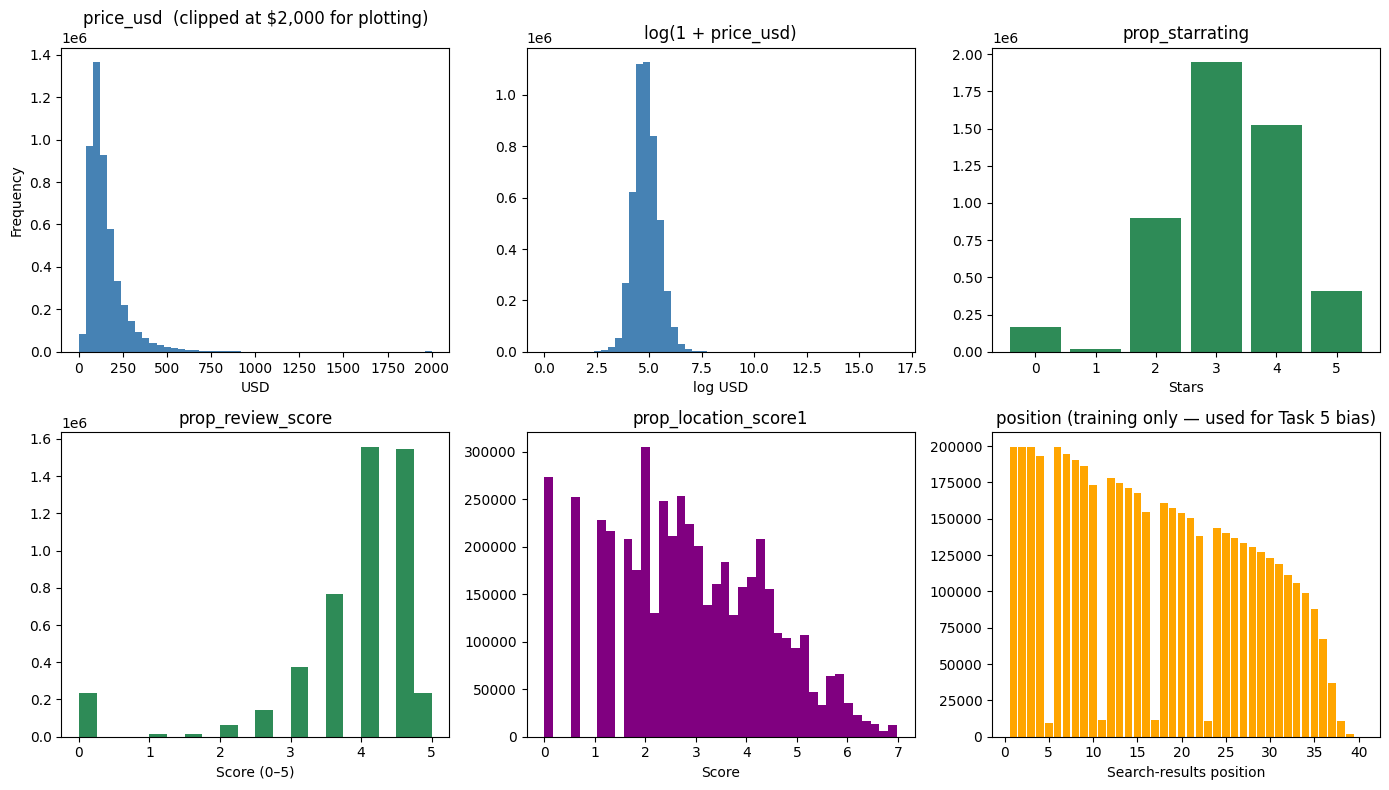

In [17]:
# =============================================================================
# Cell 6 — Distribution plots for key numeric features
# =============================================================================
# Purpose: visualise the marginal distributions of the features that Cell 5
# flagged as interesting. This is Lecture 2's "useful plots" sub-step of EDA.
#
# Why these six panels:
#   1) price_usd (raw, clipped) ........ shows the outlier problem visually
#   2) log(1 + price_usd) .............. shows the "natural" near-normal shape
#                                        — directly motivates the Task 3 log
#                                        transform
#   3) prop_starrating ................. categorical-like distribution 0..5
#   4) prop_review_score ............... continuous (rounded to 0.5)
#   5) prop_location_score1 ............ desirability score, important predictor
#   6) position ........................ near-uniform 1..40 — sets up the
#                                        Task 5 bias-investigation analysis
# =============================================================================

# `plt.subplots(rows, cols, figsize=(w_in, h_in))` creates a grid of axes.
# It returns `fig` (the whole figure) and `axes` (a 2D ndarray of subplot axes
# we can index like axes[row, col]).
fig, axes = plt.subplots(2, 3, figsize=(14, 8))


# --- Panel (0,0): raw price_usd, clipped at $2,000 for visibility -----------
# `.clip(upper=2000)` REPLACES values above 2000 with 2000; we don't drop
# them, we just bunch the tail at the cap so the bulk of the distribution
# is actually visible. (A few rows with $20M would otherwise compress the
# rest of the histogram into a single invisible bar.)
axes[0, 0].hist(train["price_usd"].clip(upper=2000), bins=50, color="steelblue")
axes[0, 0].set_title("price_usd  (clipped at $2,000 for plotting)")
axes[0, 0].set_xlabel("USD")
axes[0, 0].set_ylabel("Frequency")


# --- Panel (0,1): log(1 + price_usd) — the "natural" shape ------------------
# `np.log1p(x)` = log(1 + x). The +1 keeps the log defined when price is 0
# (rare but present). The transformed distribution should look much closer
# to a normal bell curve — that's the typical pattern for prices.
axes[0, 1].hist(np.log1p(train["price_usd"]), bins=50, color="steelblue")
axes[0, 1].set_title("log(1 + price_usd)")
axes[0, 1].set_xlabel("log USD")


# --- Panel (0,2): prop_starrating, an integer 0..5 --------------------------
# `bins=range(0, 7)` makes integer-aligned bins; `align='left'` and `rwidth`
# give it a clean bar-chart look.
axes[0, 2].hist(train["prop_starrating"], bins=range(0, 7),
                color="seagreen", align="left", rwidth=0.85)
axes[0, 2].set_title("prop_starrating")
axes[0, 2].set_xlabel("Stars")


# --- Panel (1,0): prop_review_score 0..5 in 0.5 increments ------------------
# `.dropna()` removes the small fraction of NaN review-score rows so the
# histogram doesn't error.
axes[1, 0].hist(train["prop_review_score"].dropna(), bins=20, color="seagreen")
axes[1, 0].set_title("prop_review_score")
axes[1, 0].set_xlabel("Score (0–5)")


# --- Panel (1,1): prop_location_score1 --------------------------------------
axes[1, 1].hist(train["prop_location_score1"], bins=40, color="purple")
axes[1, 1].set_title("prop_location_score1")
axes[1, 1].set_xlabel("Score")


# --- Panel (1,2): position 1..40 -------------------------------------------
# Training only — position is NOT in the test set. We're plotting it because
# its distribution sets up the bias analysis in Task 5.
axes[1, 2].hist(train["position"], bins=range(1, 42),
                color="orange", align="left", rwidth=0.85)
axes[1, 2].set_title("position (training only — used for Task 5 bias)")
axes[1, 2].set_xlabel("Search-results position")


# `tight_layout()` adjusts spacing so axis labels and titles don't overlap.
plt.tight_layout()
plt.show()


Mean relevance grade by position (first 10 positions shown):
------------------------------------------------------------
random_bool       0       1
position                   
1            0.9927  0.2132
2            0.6633  0.1616
3            0.4960  0.1415
4            0.4101  0.1193
5            0.0649  0.1030
6            0.3155  0.1064
7            0.2650  0.0898
8            0.2265  0.0801
9            0.1915  0.0739
10           0.1814  0.0674



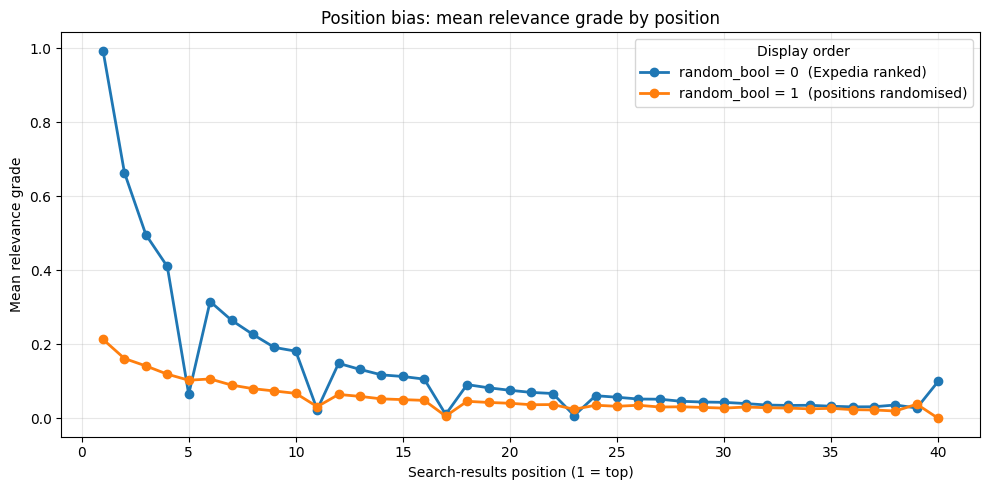

In [18]:
# =============================================================================
# Cell 7 — Position bias analysis
# =============================================================================
# Purpose: measure how user interaction (relevance grade) depends on the
# position the hotel was displayed at, separately for normal Expedia ranking
# and the randomised-sort searches. The gap between these two curves IS the
# position-bias effect (Lecture 8: Ethics / Bias).
#
# Variables we use:
#   - position      : 1 = top of the results page, larger numbers = lower
#   - random_bool   : 1 when the sort order was randomised; 0 when the normal
#                     Expedia algorithm ordered the results.
#   - relevance     : the 5/1/0 grade we built in Cell 4.
#
# Expected pattern:
#   - random_bool = 0 (normal ranking): steep decline — top positions show
#     better hotels AND people look more at top results.
#   - random_bool = 1 (randomised): roughly flat — no quality/position
#     correlation, so any remaining decline is pure visual position bias.
# =============================================================================

# `groupby([col_a, col_b])` partitions rows by both columns simultaneously.
# `["relevance"].mean()` then computes the mean relevance grade per (position,
# random_bool) combination.
# `.unstack()` pivots the second grouping key (random_bool) up into the
# columns, so we end up with a small wide table: rows = position 1..40,
# columns = random_bool 0 and 1.
pos_bias = (
    train.groupby(["position", "random_bool"])["relevance"]
    .mean()
    .unstack()
)

print("Mean relevance grade by position (first 10 positions shown):")
print("-" * 60)
print(pos_bias.head(10).round(4).to_string())
print()

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 5))
pos_bias.plot(ax=ax, marker="o", linewidth=2)

ax.set_xlabel("Search-results position (1 = top)")
ax.set_ylabel("Mean relevance grade")
ax.set_title("Position bias: mean relevance grade by position")
ax.grid(alpha=0.3)

# Override the legend labels for clarity (defaults would just be "0" and "1").
ax.legend(title="Display order",
          labels=["random_bool = 0  (Expedia ranked)",
                  "random_bool = 1  (positions randomised)"])

plt.tight_layout()
plt.show()


#### §2 — Task 3: Data Preparation and Feature Engineering

In this section we transform the raw training table into a clean, model-ready
feature matrix. We follow Lecture 2's data-preparation workflow:

1. **Handle outliers** in price-like columns (the `price_usd` max of $19.7M
   confirmed in §1 is a strong signal we need a log transform).
2. **Handle missing values** in the columns flagged in §1 — primarily the
   competitor block, `visitor_hist_*`, `orig_destination_distance`, and
   `prop_location_score2`.
3. **Engineer new features**: per-property aggregates (mean booking
   probability, average price), per-search context (price rank within search,
   price gap vs. search median), and competitor summaries (count of cheaper
   competitors, mean rate-diff).
4. **Time features** extracted from `date_time` (hour of day, day of week,
   month).
5. **Train / validation split** that respects search-query grouping — rows
   from the same `srch_id` must stay together so we don't leak label
   information across the split.

> *Tip for the report:* the rubric awards 5 points for "Dataset pre-processing
> (replicable process of feature engineering)" and 5 for "Rationale for feature
> engineering" — every transformation we apply should be paired with one
> sentence in the report explaining *why* we did it.


##### §2.1 — Price outliers and the log transformation

The descriptive statistics in §1 showed `price_usd` ranging from $0 to **$19.7
million**, while the median is $122 and the 99th percentile is around $500.
A handful of broken rows would otherwise dominate any model's loss function
and squash sensible prices into one indistinguishable bin.

The textbook fix (Lecture 2 — "Transformations") is:

1. Apply a **log transform** `log(1 + price_usd)` to compress the heavy right
   tail. The resulting distribution is roughly normal — the natural shape for
   prices in the report (also visible in Cell 6, Panel 0,1).
2. Additionally **clip** the raw column at the 99.9th percentile as defensive
   cleanup of obviously broken records, so derived per-search features like
   "price rank within search" aren't poisoned by a single $19M row.

We deliberately keep the raw `price_usd` column too — it will be used to build
**relative** price features (e.g. "price rank within search") in §2.4, where
the absolute scale doesn't matter.
